# SED Builder Demo 

The `ssdc-sedbuilder` package provides programmatic access to multi-wavelength spectral energy distribution (SED) data from catalogs, surveys, and archival observations across the electromagnetic spectrum. It is based on [SED Builder](https://tools.ssdc.asi.it/SED/), a software developed at ASI-SSDC to produce and display the SED data over the web. The [source code](https://gitrepo.ssdc.asi.it/sedbuilder/sedbuilder) and the [documentation](https://peppedilillo.github.io/sedbuilder/development/) are available online.

## Fetching data with `get_data`

The most important function of the package is called `get_data`. It queries the SSDC SED Builder API to retrieve Spectral Energy Distribution data from the main database. Data can be searched by coordinates:

In [1]:
from sedbuilder import get_data

response = get_data(ra=166.1138 , dec=38.2083)

> Note: angles are assumed in degrees. 

You can also search by the astronomical source name:

In [2]:
response = get_data(name="MRK 421")

> Note: `get_data` is _keyword only_: calling `get_data("MRK 421")` or `get_data(166.1138, 38.2083)` will result in an error, you must state the keyword name explicitly.


When `get_data` is called with the `name` argument, it resolves the source name to coordinates via SSDC name resolver, another API service offered by SSDC. You can query the SSDC name resolver directly with `resolve_name`. Calling `get_data` by coordinates is a bit faster, keep it in mind if you are going to query many sources in a loop.

In [3]:
from sedbuilder import resolve_name

(ra, dec), db = resolve_name("MRK 421")
print(f"Resolved 'MRK 421' to coordinates ra = {ra:.4f} deg and dec = {dec:.4f} deg, through the {db} database.")

Resolved 'MRK 421' to coordinates ra = 166.1138 deg and dec = 38.2088 deg, through the astropy database.


## The `Response` object

The `get_data` function outputs a `Response` object.  What's inside a SED Builder `Response`? 

Data, of course! You can access it in multiple tabular formats, for example pandas:

In [4]:
df = response.to_pandas()
df

,name,frequency,nufnu,frequency_error,nufnu_error,angular_distance,start_time,stop_time,info,reference_name,reference_band,error_radius
0,None,8.460000e+09,5.343336e-14,0.000000e+00,3.384000e-17,0.000306,47941.500000,47941.500000,,CLASSSCAT,Radio,1.00
1,J110428+381228,8.400000e+09,5.305440e-14,0.000000e+00,0.000000e+00,0.001144,NaN,NaN,,CRATES,Radio,1.00
2,B2.3 1101+38,4.080000e+08,4.692000e-15,0.000000e+00,0.000000e+00,0.214639,NaN,NaN,,DIXON,Radio,1.00
3,S4 1101+38,2.700000e+09,2.079000e-14,0.000000e+00,0.000000e+00,0.161121,NaN,NaN,,DIXON,Radio,1.00
4,S4 1101+38,1.070000e+10,8.453000e-14,0.000000e+00,0.000000e+00,0.161121,NaN,NaN,,DIXON,Radio,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...
2296,None,8.850000e+18,2.147220e-11,2.079000e+17,4.999570e-12,0.000428,57839.910498,57840.639699,,NuBlazar,None,0.15
2297,None,9.271000e+18,2.877670e-11,2.128000e+17,6.012190e-12,0.000428,57839.910498,57840.639699,,NuBlazar,None,0.15
2298,None,9.764000e+18,1.663020e-11,2.805000e+17,5.108790e-12,0.000428,57839.910498,57840.639699,,NuBlazar,None,0.15
2299,None,1.034000e+19,1.980570e-11,2.950000e+17,5.911410e-12,0.000428,57839.910498,57840.639699,,NuBlazar,None,0.15


Or astropy tables:

In [5]:
at = response.to_astropy()
at[:5] # we only show the first five rows

name,frequency,nufnu,frequency_error,nufnu_error,angular_distance,start_time,stop_time,info,reference_name,reference_band,error_radius
,Hz,erg / (s cm2),Hz,erg / (s cm2),arcsec,d,d,,,,arcsec
str23,float64,float64,float64,float64,float64,float64,float64,str39,str37,str10,float64
None,8460000000.0,5.343335955180994e-14,0.0,3.3840001528216023e-17,0.000306151995601697,47941.5,47941.5,,CLASSSCAT,Radio,1.0
J110428+381228,8400000000.0,5.305440000000001e-14,0.0,0.0,0.0011437129942777986,nan,nan,,CRATES,Radio,1.0
B2.3 1101+38,408000000.0,4.6920000000000005e-15,0.0,0.0,0.21463926273293185,nan,nan,,DIXON,Radio,1.0
S4 1101+38,2700000000.0,2.0790000000000002e-14,0.0,0.0,0.16112126096570575,nan,nan,,DIXON,Radio,1.0
S4 1101+38,10700000000.0,8.453000000000001e-14,0.0,0.0,0.16112126096570575,nan,nan,,DIXON,Radio,1.0


The response method `to_jetset` make it easy working with [JetSeT](https://github.com/andreatramacere/jetset), a popular astrophysics framework for modelling radiative and accelerative processes.

In [6]:
jt = response.to_jetset(z=0.0308) # note that you must provide a redshift value when calling `to_jetset`
jt[:5]

x,dx,y,dy,T_start,T_stop,UL,dataset
Hz,Hz,erg / (s cm2),erg / (s cm2),,,,
float64,float64,float64,float64,float64,float64,bool,str37
8460000000.0,0.0,5.343335955180994e-14,3.3840001528216023e-17,47941.5,47941.5,False,CLASSSCAT
8400000000.0,0.0,5.305440000000001e-14,0.0,0.0,0.0,False,CRATES
408000000.0,0.0,4.6920000000000005e-15,0.0,0.0,0.0,False,DIXON
2700000000.0,0.0,2.0790000000000002e-14,0.0,0.0,0.0,False,DIXON
10700000000.0,0.0,8.453000000000001e-14,0.0,0.0,0.0,False,DIXON


You can also output data from a response into a Python dict with `response.to_dict()` or into JSON with `response.to_json()`.

A response also contains metadata, for example units:

In [7]:
from pprint import pprint

pprint(response.properties.units)

{'AngularDistance': 'arcsec',
 'ErrorRadius': 'arcsec',
 'Frequency': 'Hz',
 'FrequencyError': 'Hz',
 'Nh': 'cm**-2',
 'Nufnu': 'erg cm**(-2) s**(-1)',
 'NufnuError': 'erg cm**(-2) s**(-1)',
 'StartTime': 'mjd',
 'StopTime': 'mjd'}


You may have noticed a few columns having `reference` in their name. A reference is either a catalog or paper from which SED data come from. They are accessible through the `references` method:

In [8]:
for ref in response.references():
    if ref["name"] == "CLASSSCAT":
        pprint(ref)
        break

{'band': 'Radio',
 'bibliography': [{'authors': 'Myers, S. T.; Jackson, N. J.; Browne I. W. A. '
                              'et al.',
                   'id': None,
                   'title': 'The Cosmic Lens All Sky Survey - I. Source '
                            'selection and observations',
                   'url': 'https://ui.adsabs.harvard.edu/abs/2003MNRAS.341....1M'}],
 'error_radius': 1.0,
 'id': 4143,
 'kind': 'Catalog',
 'name': 'CLASSSCAT'}


# SED Builder Data Exploration

Let's give a look to the data we just downloaded. Exporting to a pandas dataframe and using `seaborn` makes visualization very easy.

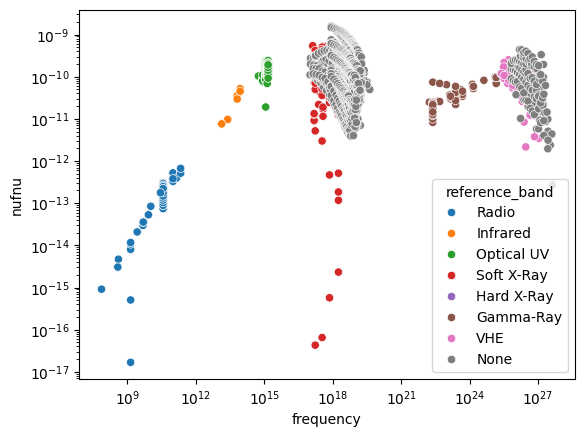

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

ax = sns.scatterplot(df, x="frequency", y="nufnu", hue="reference_band")
ax.loglog(); plt.show()

We can see that some measurements from soft X-Ray and radio references are very low flux. Maybe it's better to drop them out, based on some min-threshold SNR filter. <br>
To get a visual impression of the measure SNR we move from seaborn to matplotlib and plot the data error bars.

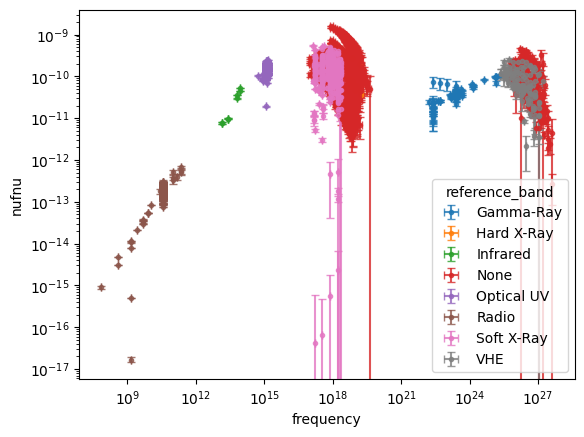

In [10]:
import pandas as pd
import matplotlib as matplotlib


def plt_errorbar(df: pd.DataFrame, ax: matplotlib.axes.Axes, hue="reference_band"):
    for band, group in df.groupby(hue):
        ax.errorbar(
            group["frequency"],
            group["nufnu"],
            xerr=group["frequency_error"],
            yerr=group["nufnu_error"],
            fmt="o",
            markersize=3,
            linestyle="none",
            label=band,
            alpha=0.8,
            capsize=3,
        )

    ax.set(xlabel="frequency", ylabel="nufnu", xscale="log", yscale="log")
    ax.legend(title=hue, loc=4)
    return ax



fig, ax = plt.subplots()
ax = plt_errorbar(df, ax)
plt.show()

Looking at the data you will find an `info` column. This is a string that may be optionally populated with warnings and other caveat on a particular data entry. We drop data with non-empty info string. We also set a SNR threshold and drop measure below that level. <br>
To achieve this, we define a simple boolean mask and index our dataframe on it.

In [11]:
SNR_THRESHOLD = 3
mask = (
    (df["info"] == "") &
    (df["nufnu"] / df["nufnu_error"] > SNR_THRESHOLD )
)

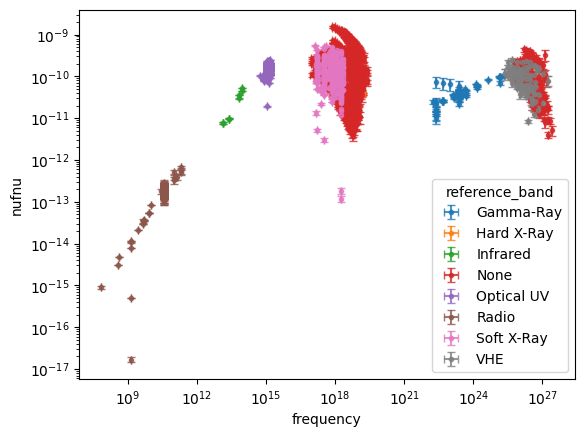

In [12]:
fig, ax = plt.subplots()
ax = plt_errorbar(df[mask], ax)
plt.show()

Much better, isn't it? However that's still a lot of data, probably too much for fitting a model! The reason of all these data is that `get_data` will return *all* the data from the SED Builder database. These data may have been collected over very large time spans. Let's check how much back in time our dataset gets. To get something easier to understand we will first convert the `start_time` and `stop_time` columns to datetime from MJD. As some of the data do not annotate a start and stop time, we will drop these entries altogether composing (OR) our filter mask.

In [13]:
mask &= ~(
    df["start_time"].isna() | df["stop_time"].isna()
)
df[mask][["start_time", "stop_time"]]

,start_time,stop_time
0,47941.500000,47941.500000
6,49078.500000,49443.500000
7,49078.500000,49443.500000
8,49078.500000,49443.500000
11,53425.895000,53425.911204
...,...,...
2296,57839.910498,57840.639699
2297,57839.910498,57840.639699
2298,57839.910498,57840.639699
2299,57839.910498,57840.639699


In [14]:
from astropy.time import Time

start_dt = pd.Series(Time(df[mask]["start_time"].to_numpy(), format="mjd", scale="utc").to_datetime(), name="start_dt")
start_dt.describe()

count                          2096
mean     2008-09-15 19:46:10.844881
min             1978-11-01 12:00:00
25%      2004-05-08 23:51:00.000012
50%      2010-01-17 00:16:02.496000
75%      2013-04-11 01:01:02.999971
max      2022-12-06 15:03:53.280000
Name: start_dt, dtype: object

Some of the data dates back to 1978! Let's visualize a timeline of the observations.

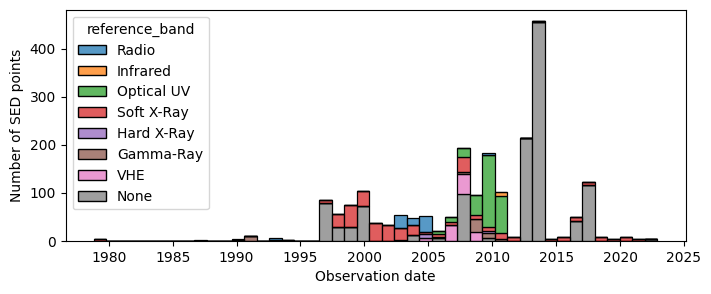

In [15]:
activity_df = pd.DataFrame({
    "start_dt": start_dt,
    "reference_band": df.loc[mask, "reference_band"].to_numpy(),
})

fig, ax = plt.subplots(figsize=(8, 3))
sns.histplot(
    activity_df,
    x="start_dt",
    hue="reference_band",
    multiple="stack",
    bins=start_dt.max().year - start_dt.min().year + 1, 
    ax=ax,
)
ax.set(xlabel="Observation date", ylabel="Number of SED points")
plt.show()

During 2008, 2009, 2013 and 2015 MRK 421 went through a period of significant flaring activity [[1]](https://ui.adsabs.harvard.edu/abs/2009ApJ...691L..13D) [[2]](https://www.aanda.org/articles/aa/pdf/2012/05/aa18569-11.pdf) [[3]](https://iopscience.iop.org/article/10.1088/0004-637X/811/2/143/meta). This nicely evident in the timeline above. Let's try to get SED data for these periods.

In [16]:
tstart, tstop = Time("2008-05-23").mjd, Time("2008-06-24").mjd
mask_t = mask & (
    (df["stop_time"] > tstart) &
    (df["start_time"] < tstop) 
)

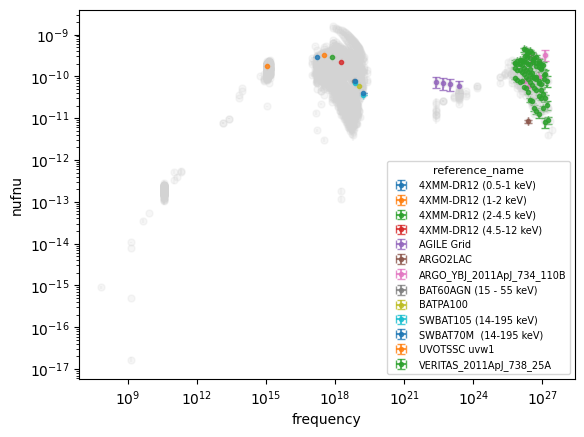

In [17]:
fig, ax = plt.subplots()
ax.errorbar(
    df.loc[mask, "frequency"],
    df.loc[mask, "nufnu"],
    xerr=df.loc[mask, "frequency_error"],
    yerr=df.loc[mask, "nufnu_error"],
    fmt="o",
    markersize=5,
    linestyle="none",
    color="lightgrey",
    alpha=0.2,
    label="_nolegend_",
)

ax = plt_errorbar(df[mask_t], ax, hue="reference_name")
ax.legend(title="reference_name", loc=4, fontsize=7, title_fontsize=8)
plt.show()

## Exporting data selections to JeTSeT

We got a nice selection of data from a MRK 421, over period of particularly interesting flaring activity. To fit a model with jetset, we must apply our pandas-native mask to a JeTSeT astropy table. This is straightforward:

In [18]:
jt = response.to_jetset(z = 0.031)
jt = jt[mask_t.values]
jt

x,dx,y,dy,T_start,T_stop,UL,dataset
Hz,Hz,erg / (s cm2),erg / (s cm2),,,,
float64,float64,float64,float64,float64,float64,bool,str37
1157000000000000.0,0.0,1.8000050061584005e-10,7.574123077856709e-13,54629.883715,54629.883715,False,UVOTSSC uvw1
1.71e+17,0.0,2.8326799239586364e-10,3.2173498891105434e-13,54617.109085648146,54617.209710648145,False,4XMM-DR12 (0.5-1 keV)
3.419e+17,0.0,3.217180133407993e-10,3.832039937104459e-13,54617.109085648146,54617.209710648145,False,4XMM-DR12 (1-2 keV)
7.254e+17,0.0,2.9436800219606596e-10,6.134899988192999e-13,54617.109085648146,54617.209710648145,False,4XMM-DR12 (2-4.5 keV)
1.777e+18,0.0,2.209540050923664e-10,8.545830059228376e-13,54617.109085648146,54617.209710648145,False,4XMM-DR12 (4.5-12 keV)
6.945e+18,0.0,7.943638598833844e-11,9.467984323363972e-13,53430.0,55256.0,False,BAT60AGN (15 - 55 keV)
1.147e+19,0.0,5.8022e-11,5.628999793459e-13,53576.425781,55346.425781,False,BATPA100
7.254e+18,0.0,6.942376476456568e-11,5.465278101926485e-13,53340.5,56535.5,False,SWBAT105 (14-195 keV)


Here it is, ready for modelling!

## Getting help

All functions in the package are documented. It is easy to recover the documentation at runtime:

In [ ]:
get_data??

Hope you enjoyed this tutorial and 'till next time.. o7